In [9]:
# CELL 1 — Imports & Config
import os
import json
from pathlib import Path
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Paths
OUT_DIR = Path("artifact")
HEATMAP_DIR = OUT_DIR/"heatmaps"
LABEL_FILE = OUT_DIR/"labels.json"
MODEL_DIR = OUT_DIR/"models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


In [10]:
# CELL 2 — Load metadata & splits
meta = json.load(open(LABEL_FILE))
samples = [(m["file"], 1 if m["class"]=="metal" else 0) for m in meta]

# stratified split: train+val/test
trainval, test = train_test_split(
    samples, test_size=0.12, stratify=[s[1] for s in samples], random_state=SEED
)
train, val = train_test_split(
    trainval, test_size=0.15, stratify=[s[1] for s in trainval], random_state=SEED
)

print("Total:", len(samples), "Train:", len(train), "Val:", len(val), "Test:", len(test))


Total: 600 Train: 448 Val: 80 Test: 72


In [3]:
# CELL 3 — Compute dataset-wide mean and std (single-channel)
from tqdm import tqdm

def compute_mean_std(file_list, resize_to=None):
    s = 0.0
    s2 = 0.0
    count = 0
    for fp,label in tqdm(file_list, desc="Computing mean/std"):
        img = Image.open(fp).convert("L")
        if resize_to:
            img = img.resize(resize_to, Image.BICUBIC)
        arr = np.array(img, dtype=np.float32) / 255.0
        s += arr.mean()
        s2 += (arr**2).mean()
        count += 1
    mean = s / count
    var = s2 / count - mean**2
    std = max(np.sqrt(var), 1e-6)
    return float(mean), float(std)

# Use a moderate resolution to compute stats (we will use transforms.Resize later)
mean, std = compute_mean_std(train, resize_to=(128,128))
print("Dataset mean, std:", mean, std)


Computing mean/std: 100%|██████████| 448/448 [00:00<00:00, 3700.12it/s]

Dataset mean, std: 0.5777407288551331 0.2524840235710144


In [11]:
# CELL 4 — Dataset class
class HeatmapDataset(Dataset):
    def __init__(self, items, transform=None):
        self.items = items
        self.transform = transform

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        fp, label = self.items[idx]
        img = Image.open(fp).convert("L")
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.long)


In [18]:
# CELL 5 — Transforms & DataLoaders
IMG_SIZE = 128
BATCH_SIZE = 32

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomApply([transforms.RandomRotation(8)], p=0.3),
    transforms.RandomApply([transforms.RandomAffine(0, translate=(0.05,0.05))], p=0.3),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[mean], std=[std])
])

val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[mean], std=[std])
])

train_loader = DataLoader(HeatmapDataset(train, train_tf), batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(HeatmapDataset(val, val_tf), batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(HeatmapDataset(test, val_tf), batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print("DataLoaders ready — batches:", len(train_loader), len(val_loader), len(test_loader))


DataLoaders ready — batches: 14 3 3


In [19]:
# CELL 6 — Model definition & helpers
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=3, pool=True):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, kernel, padding=kernel//2, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        ]
        if pool:
            layers.append(nn.MaxPool2d(2))
        self.block = nn.Sequential(*layers)
    def forward(self, x):
        return self.block(x)

class MetalCNN(nn.Module):
    def __init__(self, in_ch=1, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(in_ch, 32),
            ConvBlock(32, 64),
            ConvBlock(64, 128),
            ConvBlock(128, 256, pool=True)
        )
        # compute final spatial size after 4 poolings: IMG_SIZE / 2^4
        final_spatial = IMG_SIZE // (2**4)
        self.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(256 * final_spatial * final_spatial, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

model = MetalCNN().to(device)
print(model)


MetalCNN(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (2): ConvBlock(
      (block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  

In [20]:
# CELL 7 — Training setup
from collections import deque

# Compute class weights (to handle any slight imbalance)
labels_train = [lab for _,lab in train]
class_counts = np.bincount(labels_train)
class_weights = torch.tensor([len(labels_train)/c for c in class_counts], dtype=torch.float32)
class_weights = class_weights.to(device)
print("Class counts:", class_counts, "Class weights:", class_weights.cpu().numpy())

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

# FIX: Remove verbose=True (not supported in your PyTorch version)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=3
)

# Early stopping
PATIENCE = 7
best_val = 0.0
epochs_no_improve = 0
best_path = MODEL_DIR/"best_model.pth"

# For plotting
train_losses, val_losses = [], []
train_accs, val_accs = [], []


Class counts: [224 224] Class weights: [2. 2.]


In [21]:
# CELL 8 — Training loop
EPOCHS = 40
grad_clip = 1.0

for epoch in range(1, EPOCHS+1):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for x,y in train_loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        # gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()

        running_loss += loss.item() * x.size(0)
        preds = out.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += x.size(0)

    train_loss = running_loss / total
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # Validation
    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for x,y in val_loader:
            x = x.to(device)
            y = y.to(device)
            out = model(x)
            loss = criterion(out, y)
            val_running_loss += loss.item() * x.size(0)
            preds = out.argmax(dim=1)
            val_correct += (preds == y).sum().item()
            val_total += x.size(0)

    val_loss = val_running_loss / val_total
    val_acc = val_correct / val_total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    # Scheduler step (monitoring val_acc)
    scheduler.step(val_acc)

    print(f"Epoch {epoch:02d} Train Loss {train_loss:.4f} Acc {train_acc:.3f} | Val Loss {val_loss:.4f} Acc {val_acc:.3f}")

    # Checkpointing
    if val_acc > best_val + 1e-6:
        best_val = val_acc
        epochs_no_improve = 0
        torch.save(model.state_dict(), best_path)
        print("  → New best model saved.")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"No improvement for {PATIENCE} epochs. Early stopping.")
            break

print("Training finished. Best val acc:", best_val)


Epoch 01 Train Loss 3.0403 Acc 0.625 | Val Loss 2.7822 Acc 0.550
  → New best model saved.
Epoch 02 Train Loss 1.0302 Acc 0.770 | Val Loss 0.5986 Acc 0.838
  → New best model saved.
Epoch 03 Train Loss 0.5665 Acc 0.781 | Val Loss 0.9252 Acc 0.725
Epoch 04 Train Loss 0.4553 Acc 0.779 | Val Loss 0.9830 Acc 0.738
Epoch 05 Train Loss 0.3218 Acc 0.824 | Val Loss 0.4298 Acc 0.825
Epoch 06 Train Loss 0.3688 Acc 0.846 | Val Loss 0.4057 Acc 0.838
Epoch 07 Train Loss 0.4583 Acc 0.815 | Val Loss 0.3562 Acc 0.838
Epoch 08 Train Loss 0.2832 Acc 0.826 | Val Loss 0.2924 Acc 0.850
  → New best model saved.
Epoch 09 Train Loss 0.2874 Acc 0.882 | Val Loss 0.3451 Acc 0.863
  → New best model saved.
Epoch 10 Train Loss 0.2800 Acc 0.862 | Val Loss 0.3613 Acc 0.850
Epoch 11 Train Loss 0.2762 Acc 0.882 | Val Loss 0.3136 Acc 0.850
Epoch 12 Train Loss 0.2518 Acc 0.862 | Val Loss 0.3675 Acc 0.825
Epoch 13 Train Loss 0.2482 Acc 0.871 | Val Loss 0.3133 Acc 0.863
Epoch 14 Train Loss 0.2483 Acc 0.873 | Val Loss 0.2

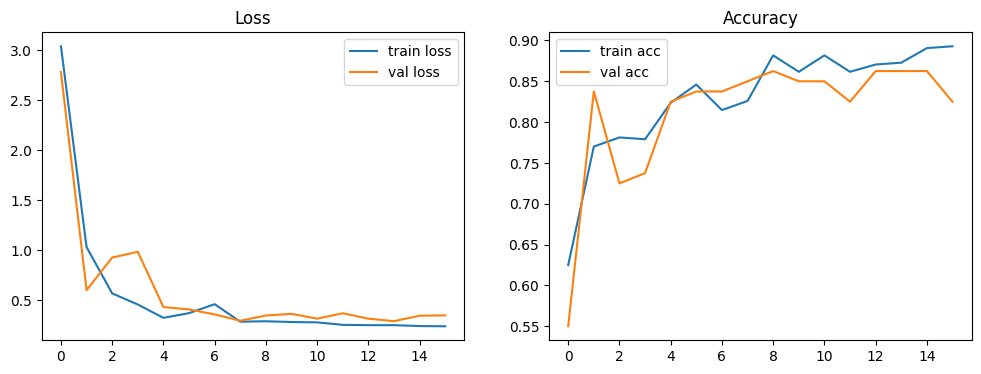

Loaded best model from: artifact\models\best_model.pth


In [23]:
# CELL 9 — Plots & load best
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(train_losses, label="train loss")
plt.plot(val_losses, label="val loss")
plt.legend()
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(train_accs, label="train acc")
plt.plot(val_accs, label="val acc")
plt.legend()
plt.title("Accuracy")
plt.show()

# load best
model.load_state_dict(torch.load(best_path, map_location=device))
model.eval()
print("Loaded best model from:", best_path)


              precision    recall  f1-score   support

    nonmetal       0.89      0.94      0.92        36
       metal       0.94      0.89      0.91        36

    accuracy                           0.92        72
   macro avg       0.92      0.92      0.92        72
weighted avg       0.92      0.92      0.92        72



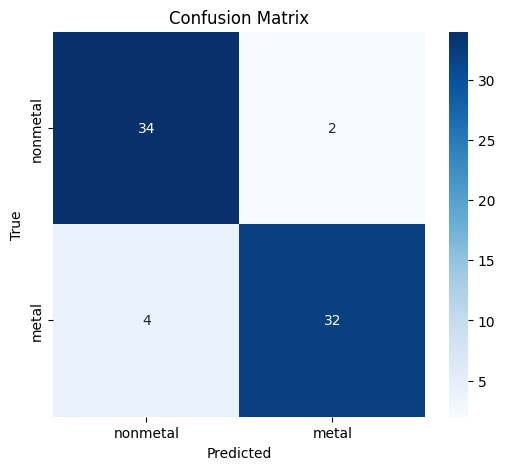

In [24]:
# CELL 10 — Final evaluation on test set
y_true, y_pred = [], []

with torch.no_grad():
    for x,y in test_loader:
        x = x.to(device)
        out = model(x)
        preds = out.argmax(dim=1).cpu().numpy()
        y_pred.extend(preds.tolist())
        y_true.extend(y.numpy().tolist())

print(classification_report(y_true, y_pred, target_names=["nonmetal","metal"]))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["nonmetal","metal"], yticklabels=["nonmetal","metal"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()
